In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import cleaning_utils as cu
import importlib
importlib.reload(cu)
import missingno as msno
from scipy.stats import chi2_contingency

In [50]:
df = pd.read_csv('../../../data/bonbanh/raw/used-car-prices.csv')
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 28477 entries, 0 to 28476
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   url             28477 non-null  str    
 1   brand           28477 non-null  str    
 2   model           28477 non-null  str    
 3   trim            28477 non-null  str    
 4   date            28477 non-null  str    
 5   price           28477 non-null  int64  
 6   year            28477 non-null  int64  
 7   status          28477 non-null  str    
 8   origin          28477 non-null  str    
 9   style           28477 non-null  str    
 10  transmission    28477 non-null  str    
 11  engine          28477 non-null  str    
 12  volume          26399 non-null  float64
 13  exterior_color  28477 non-null  str    
 14  interior_color  28477 non-null  str    
 15  seats           28477 non-null  int64  
 16  doors           28477 non-null  int64  
 17  drive           28477 non-null  str    
 1

In [51]:
missing_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_rate': df.isna().mean()*100
})

missing_summary = missing_summary[
    missing_summary['missing_count'] > 0
].sort_values(
    by='missing_rate',
    ascending=False
)

print(missing_summary)

          missing_count  missing_rate
odo                5584     19.608807
volume             2078      7.297117
province            503      1.766338


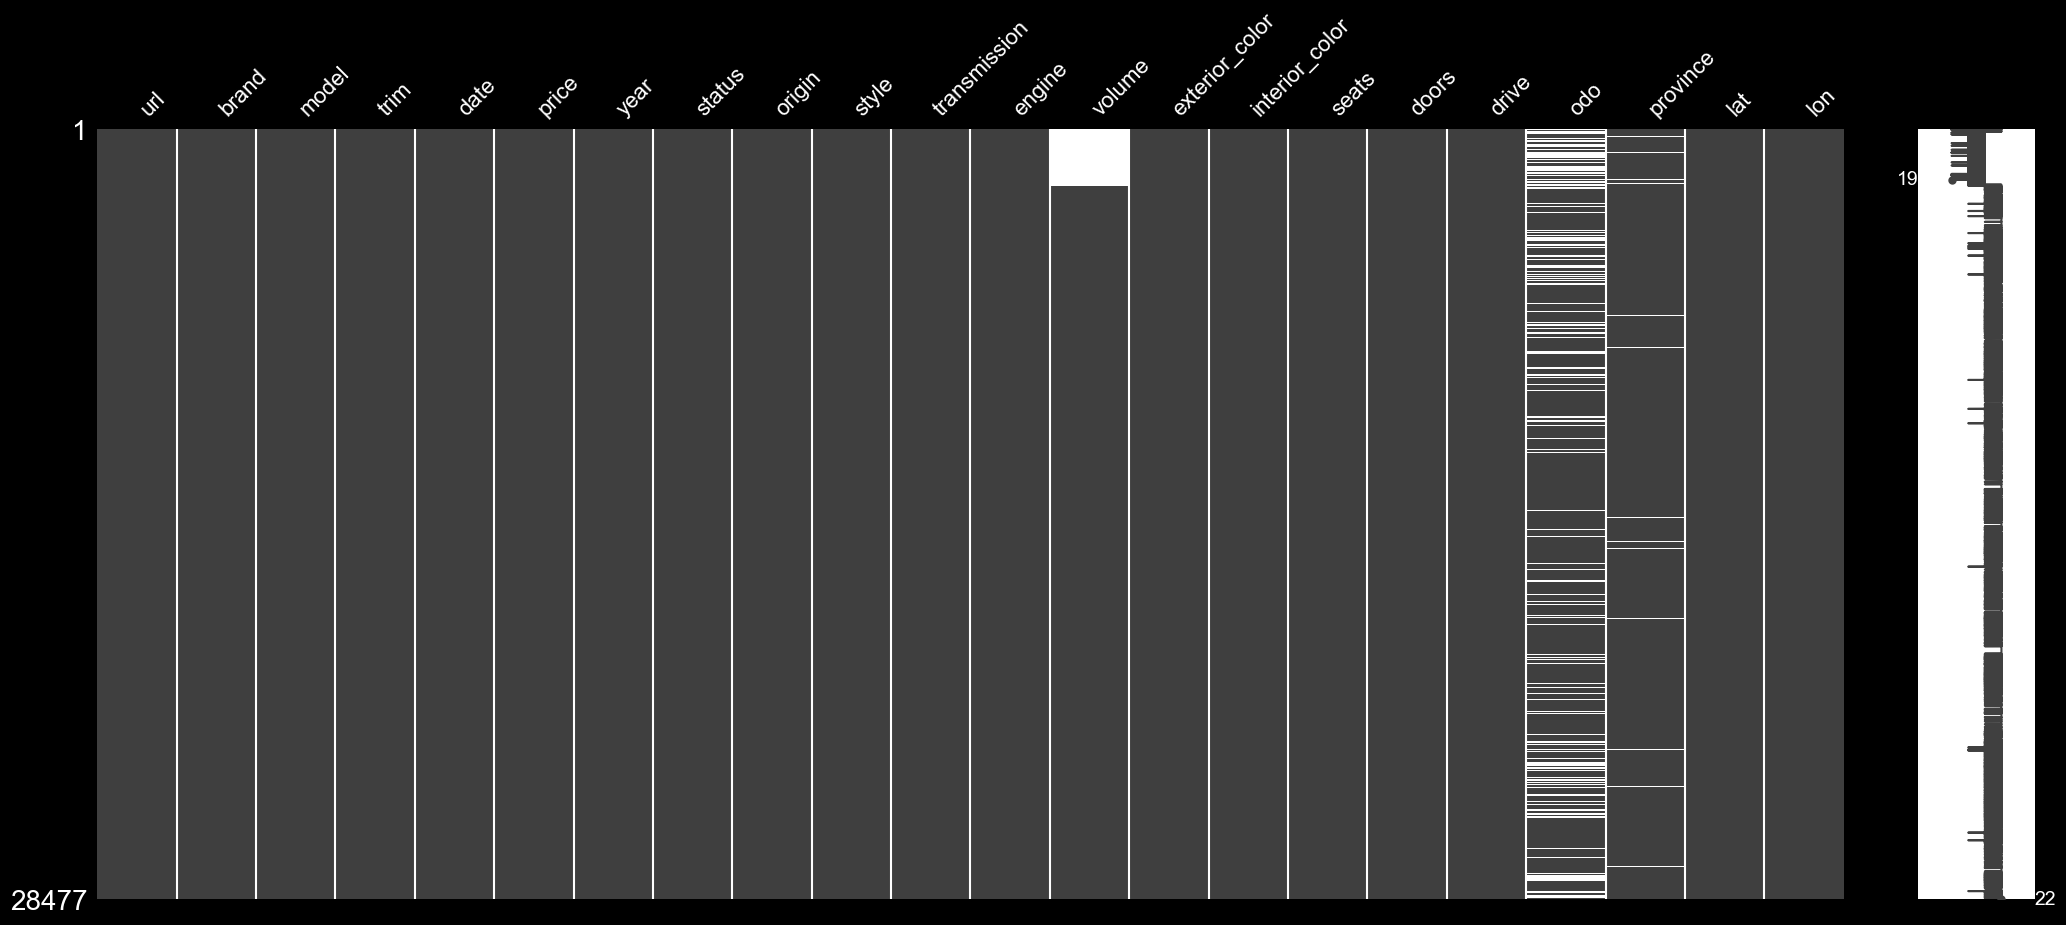

In [52]:
msno.matrix(df)
plt.savefig(
    'missing.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## Cleaning ##

In [53]:
df = cu.duplicates_remv(df)
df = cu.noisy_inconsistent_logic(df)

## Handle missing values: ##


### - Odo ###

In [54]:
print(df['status'].value_counts())

status
used    22771
new      5567
Name: count, dtype: int64


In [55]:
table = pd.crosstab(
    df['status'],
    df['odo'].isna()
)
print(table)

odo     False  True 
status              
new         0   5567
used    22771      0


Missing `odo` phụ thuộc hoàn toàn vào biến `status` --> MAR. Nhóm quyết định impute odo theo logic: Nếu `status`='new' thì `odo`=0.

In [56]:
df = cu.impute_missing_odo(df)
print(df['odo'].isna().sum())

0


### - Province ###

In [57]:
print('Số missing province:',df['province'].isna().sum())
df[df['province'].isna()][
    ['lat', 'lon']
].head()

Số missing province: 501


,lat,lon
14,26.492533,92.330879
19,26.492533,92.330879
20,26.492533,92.330879
22,26.492533,92.330879
24,26.492533,92.330879


Biến `province` có 503 giá trị khuyết, chiếm khoảng 1.8% tổng số bản ghi. Qua quá trình kiểm tra dữ liệu, các bản ghi bị thiếu `province` đồng thời xuất hiện cùng một cặp tọa độ (`lat`, `lon`) bất thường và không thuộc phạm vi địa lý của Việt Nam. Điều này cho thấy các giá trị khuyết nhiều khả năng phát sinh từ lỗi trong quá trình thu thập hoặc chuyển đổi dữ liệu địa lý (geocoding/mapping), thay vì do đặc tính ngẫu nhiên của dữ liệu.

Do cơ chế thiếu dữ liệu có thể được giải thích bởi các thông tin quan sát được trong quá trình xử lý dữ liệu, biến `province` được xem là phù hợp với cơ chế MAR (Missing At Random) hơn là MCAR (Missing Completely At Random). Tuy nhiên, do trường địa chỉ gốc không còn được lưu trữ trong tập dữ liệu hiện tại, việc khôi phục chính xác giá trị tỉnh/thành cho các bản ghi bị thiếu là không khả thi.

Bên cạnh đó, tỷ lệ dữ liệu khuyết của biến `province` chỉ chiếm 1.8%, tương đương 503 trên tổng số 28,477 bản ghi. Việc loại bỏ các bản ghi này không làm ảnh hưởng đáng kể đến quy mô và tính đại diện của tập dữ liệu. Vì vậy, nhóm quyết định loại bỏ các bản ghi bị thiếu `province` bằng phương pháp Listwise Deletion nhằm đảm bảo tính chính xác của dữ liệu đầu vào và tránh đưa các giá trị suy diễn không đáng tin cậy vào quá trình huấn luyện mô hình.


In [58]:
# Drop mising "Province"
df = df.dropna(subset=['province'])
print(df['province'].isna().sum())

0


### - Volume ###


In [59]:
df['volume_missing'] = df['volume'].isna().astype(int)

In [60]:
categorical_cols = [
    'brand',
    'model',
    'status',
    'origin',
    'style',
    'transmission',
    'drive'
]

results = []

for col in categorical_cols:
    table = pd.crosstab(
        df[col],
        df['volume_missing']
    )

    _, p, _, _ = chi2_contingency(table)

    results.append({
        'feature': col,
        'p_value': p
    })

pd.DataFrame(results).sort_values('p_value')

,feature,p_value
0,brand,0.000000e+00
1,model,0.000000e+00
2,status,0.000000e+00
4,style,0.000000e+00
3,origin,1.002619e-261
5,transmission,5.805742e-48
6,drive,8.910393e-37


Kết quả kiểm định Chi-square chỉ ra trạng thái missing của volume phụ thuộc vào các biến quan sát được như brand, model, style và status (p < 0.05), cho thấy cơ chế thiếu dữ liệu thuộc nhóm MAR. Do đó, phương pháp hierarchical median imputation được áp dụng. Các giá trị khuyết được thay thế lần lượt bằng trung vị của nhóm (brand, model), sau đó đến brand, style, và cuối cùng là trung vị toàn bộ tập dữ liệu đối với các trường hợp còn lại.

In [61]:
df = df.drop(columns=['volume_missing'])
df = cu.handle_volume(df)

Missing ban đầu: 1960
Missing còn lại: 0


## Standardization: ##

### Transmission ###

In [62]:
print(df['transmission'].value_counts())

transmission
automatic    25284
Số tay        2553
Name: count, dtype: int64


In [63]:
# Change value "Số tay"  "manual" in feature transmission
df['transmission'] = df['transmission'].replace('Số tay', 'manual')
print(df['transmission'].value_counts())

transmission
automatic    25284
manual        2553
Name: count, dtype: int64


In [64]:
cu.save_csv(df,'../../../data/bonbanh/cleaned')

Saved: ../../../data/bonbanh/cleaned\cleaned_bonbanh.csv
